In [1]:
!pip install -q mediapipe


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 9.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


In [2]:
import os
import cv2
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import mediapipe as mp
from mediapipe.tasks.python import vision, BaseOptions

from skimage.feature import hog

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, VGG16
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mnet_preprocess
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

np.random.seed(42)
tf.random.set_seed(42)

emotion_names = ['anger', 'disgust', 'fear', 'happy', 'sadness', 'surprise', 'neutral']

print("TensorFlow:", tf.__version__)
print("MediaPipe:", mp.__version__)


TensorFlow: 2.20.0
MediaPipe: 1.0.1


In [3]:
MODEL_PATH = "face_landmarker.task"
MODEL_URL = ("https://storage.googleapis.com/mediapipe-models/face_landmarker/"
             "face_landmarker/float16/1/face_landmarker.task")

if not os.path.exists(MODEL_PATH):
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print("Downloaded face landmarker model.")

landmarker_options = vision.FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=MODEL_PATH),
    num_faces=1,
    min_face_detection_confidence=0.3,
)
face_landmarker = vision.FaceLandmarker.create_from_options(landmarker_options)

LEFT_EYE_CORNER = 33
RIGHT_EYE_CORNER = 263
OUT_SIZE = 128

def get_landmarks(rgb_image):
    """Returns an (N, 2) array of pixel-coordinate landmarks, or None if no face found."""
    h, w = rgb_image.shape[:2]
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_image)
    result = face_landmarker.detect(mp_image)
    if not result.face_landmarks:
        return None
    pts = result.face_landmarks[0]
    return np.array([[p.x * w, p.y * h] for p in pts])

def align_and_crop(rgb_image, landmarks, out_size=OUT_SIZE, margin=0.25):
    left_eye = landmarks[LEFT_EYE_CORNER]
    right_eye = landmarks[RIGHT_EYE_CORNER]

    dy = right_eye[1] - left_eye[1]
    dx = right_eye[0] - left_eye[0]
    angle = np.degrees(np.arctan2(dy, dx))

    h, w = rgb_image.shape[:2]
    center = (w // 2, h // 2)
    rot_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated_img = cv2.warpAffine(rgb_image, rot_matrix, (w, h))

    ones = np.ones((landmarks.shape[0], 1))
    lm_hom = np.hstack([landmarks, ones])
    rotated_lm = (rot_matrix @ lm_hom.T).T

    x_min, y_min = rotated_lm.min(axis=0)
    x_max, y_max = rotated_lm.max(axis=0)
    box_w, box_h = x_max - x_min, y_max - y_min
    x_min -= margin * box_w; x_max += margin * box_w
    y_min -= margin * box_h; y_max += margin * box_h

    x_min, y_min = max(0, int(x_min)), max(0, int(y_min))
    x_max, y_max = min(w, int(x_max)), min(h, int(y_max))

    face_crop = rotated_img[y_min:y_max, x_min:x_max]
    face_crop = cv2.resize(face_crop, (out_size, out_size))
    return face_crop

def detect_align_batch(images, labels, dataset_name=""):
    """Runs landmark detection + alignment on a list of images, dropping any where no face is found."""
    aligned, valid_labels = [], []
    for i, img in enumerate(images):
        lm = get_landmarks(img)
        if lm is not None:
            aligned.append(align_and_crop(img, lm))
            valid_labels.append(labels[i])
        if (i + 1) % 200 == 0:
            print(f"  [{dataset_name}] landmark detection: {i+1}/{len(images)} processed")
    print(f"[{dataset_name}] Landmarks detected + aligned for {len(aligned)}/{len(images)} images")
    return np.array(aligned), np.array(valid_labels)

print("Landmark detector ready.")


Downloaded face landmarker model.
Landmark detector ready.


W0000 00:00:1788431047.254298      80 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1788431047.277496      84 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1788431047.298688      84 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## Step 2 — Load RAF-DB Training Sample (200 Images per Emotion)

**Update `rafdb_train_path` below** if your dataset path differs. This uses the balanced RAF-DB
dataset's own emotion-named folders under `train/`.


In [4]:
rafdb_train_path = "/kaggle/input/datasets/dollyprajapati182/balanced-raf-db-dataset-7575-grayscale/train"

rafdb_label_map = {   
    'angry':    0, 
    'disgust':  1,
    'fear':     2,
    'happy':    3,
    'sad':      4, 
    'surprise': 5,
    'neutral':  6,
}

SAMPLES_PER_CLASS = 200

rafdb_images, rafdb_labels = [], []

if os.path.isdir(rafdb_train_path):
    for folder_name, our_label in rafdb_label_map.items():
        folder_path = os.path.join(rafdb_train_path, folder_name)
        if not os.path.isdir(folder_path):
            print(f"Warning: folder not found for label {our_label} ({emotion_names[our_label]}): {folder_path}")
            continue
        img_files = sorted(os.listdir(folder_path))[:SAMPLES_PER_CLASS]
        for fname in img_files:
            img = Image.open(os.path.join(folder_path, fname)).convert('RGB')
            rafdb_images.append(np.array(img))
            rafdb_labels.append(our_label)
        print(f"{emotion_names[our_label]:>10}: loaded {len(img_files)} images")

    rafdb_labels = np.array(rafdb_labels)
    print(f"\nTotal RAF-DB training images loaded: {len(rafdb_images)}")
else:
    print(f"RAF-DB path not found: {rafdb_train_path}")
    print("Update 'rafdb_train_path' above to point at your dataset, then re-run this cell.")


     anger: loaded 200 images
   disgust: loaded 200 images
      fear: loaded 200 images
     happy: loaded 200 images
   sadness: loaded 200 images
  surprise: loaded 200 images
   neutral: loaded 200 images

Total RAF-DB training images loaded: 1400


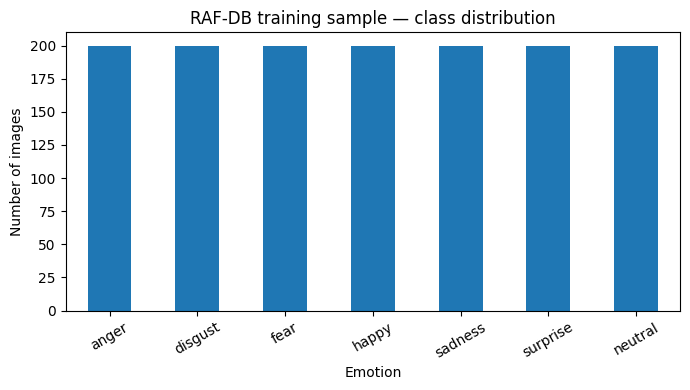

In [5]:
counts_rafdb = pd.Series(rafdb_labels).map(dict(enumerate(emotion_names))).value_counts()
plt.figure(figsize=(7, 4))
counts_rafdb.plot(kind='bar')
plt.title("RAF-DB training sample — class distribution")
plt.ylabel("Number of images")
plt.xlabel("Emotion")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


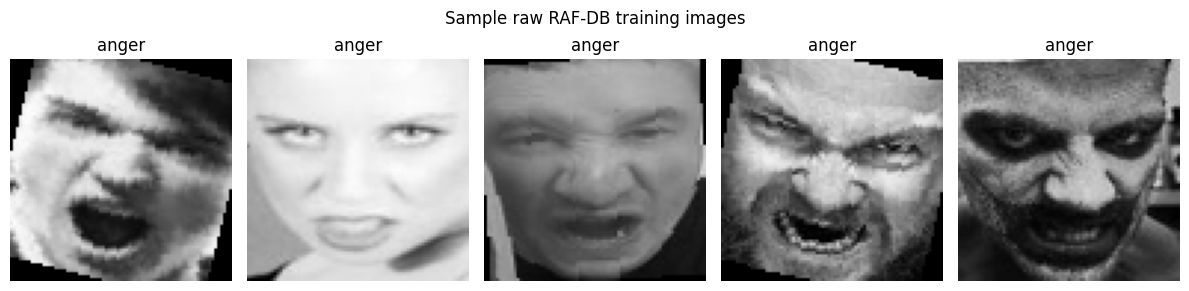

In [6]:
plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(rafdb_images[i])
    plt.title(emotion_names[rafdb_labels[i]])
    plt.axis('off')
plt.suptitle("Sample raw RAF-DB training images")
plt.tight_layout()
plt.show()


## Step 3 — Landmark Detection + Alignment on RAF-DB



In [7]:
rafdb_aligned, rafdb_labels_aligned = detect_align_batch(rafdb_images, rafdb_labels, dataset_name="RAF-DB train")


  [RAF-DB train] landmark detection: 200/1400 processed
  [RAF-DB train] landmark detection: 400/1400 processed
  [RAF-DB train] landmark detection: 600/1400 processed
  [RAF-DB train] landmark detection: 800/1400 processed
  [RAF-DB train] landmark detection: 1000/1400 processed
  [RAF-DB train] landmark detection: 1200/1400 processed
  [RAF-DB train] landmark detection: 1400/1400 processed
[RAF-DB train] Landmarks detected + aligned for 1271/1400 images


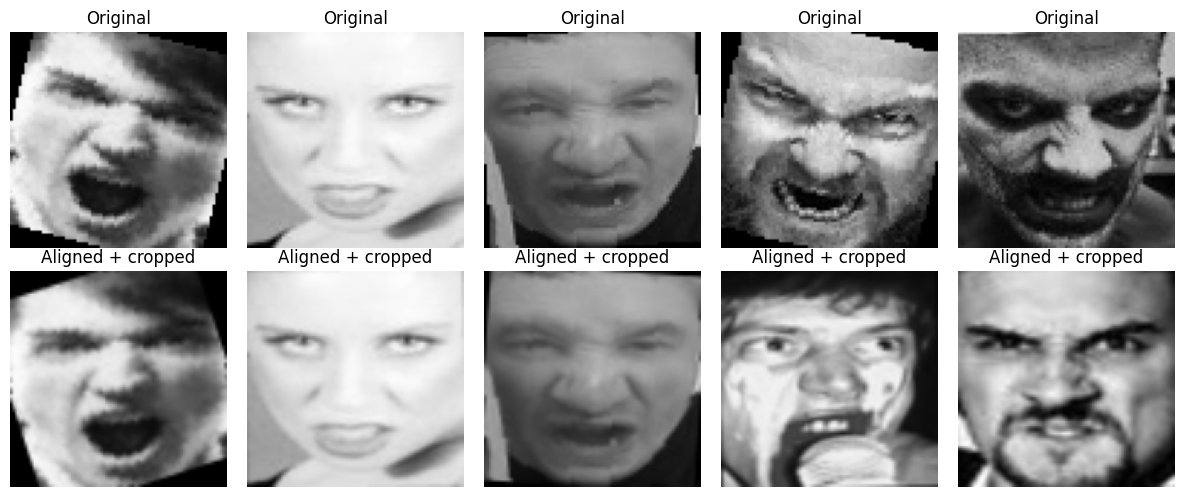

In [8]:
plt.figure(figsize=(12, 5))
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(rafdb_images[i])
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2, 5, i + 6)
    plt.imshow(rafdb_aligned[i])
    plt.title("Aligned + cropped")
    plt.axis('off')
plt.tight_layout()
plt.show()


## Step 4 — Feature Extraction on RAF-DB: HOG + MobileNetV2 + VGG16

In [9]:
mobilenet = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')
vgg = VGG16(weights='imagenet', include_top=False, pooling='avg')

def extract_cnn_features(images, model, preprocess_fn):
    features = []
    for img in images:
        img_r = cv2.resize(img, (224, 224))
        img_r = preprocess_fn(img_r.astype('float32'))
        img_r = np.expand_dims(img_r, axis=0)
        feat = model.predict(img_r, verbose=0)
        features.append(feat.flatten())
    return np.array(features)

def extract_hog_features(images):
    gray_images = np.array([cv2.cvtColor(f, cv2.COLOR_RGB2GRAY) for f in images])
    return np.array([
        hog(img, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2))
        for img in gray_images
    ])


/tmp/ipykernel_24/4140365038.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')
I0000 00:00:1788431077.765291      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788431077.768184      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
rafdb_hog = extract_hog_features(rafdb_aligned)
print("RAF-DB HOG done:", rafdb_hog.shape)

rafdb_mobilenet = extract_cnn_features(rafdb_aligned, mobilenet, mnet_preprocess)
print("RAF-DB MobileNet done:", rafdb_mobilenet.shape)

rafdb_vgg = extract_cnn_features(rafdb_aligned, vgg, vgg_preprocess)
print("RAF-DB VGG done:", rafdb_vgg.shape)


RAF-DB HOG done: (1271, 8100)


2026-09-03 10:24:59.101116: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-03 10:24:59.236228: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-03 10:24:59.368952: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1788431100.699041     103 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


RAF-DB MobileNet done: (1271, 1280)
RAF-DB VGG done: (1271, 512)


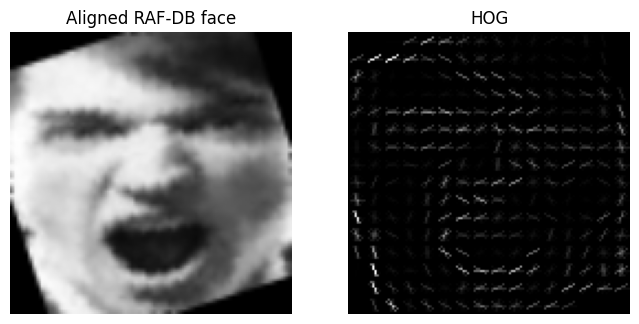

In [11]:
# HOG visualization on one RAF-DB sample
sample_gray = cv2.cvtColor(rafdb_aligned[0], cv2.COLOR_RGB2GRAY)
_, hog_image = hog(
    sample_gray, orientations=9, pixels_per_cell=(8, 8),
    cells_per_block=(2, 2), visualize=True
)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_gray, cmap='gray')
plt.title("Aligned RAF-DB face")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG")
plt.axis('off')
plt.show()


## Step 5 — Scale Each Feature Type and Concatenate




In [12]:
hog_scaler = StandardScaler()
mnet_scaler = StandardScaler()
vgg_scaler = StandardScaler()

rafdb_hog_scaled = hog_scaler.fit_transform(rafdb_hog)
rafdb_mnet_scaled = mnet_scaler.fit_transform(rafdb_mobilenet)
rafdb_vgg_scaled = vgg_scaler.fit_transform(rafdb_vgg)

X_train_concat = np.concatenate([rafdb_hog_scaled, rafdb_mnet_scaled, rafdb_vgg_scaled], axis=1)
y_train = rafdb_labels_aligned

print("HOG scaled:", rafdb_hog_scaled.shape)
print("MobileNet scaled:", rafdb_mnet_scaled.shape)
print("VGG scaled:", rafdb_vgg_scaled.shape)
print("Concatenated training feature shape:", X_train_concat.shape)


HOG scaled: (1271, 8100)
MobileNet scaled: (1271, 1280)
VGG scaled: (1271, 512)
Concatenated training feature shape: (1271, 9892)


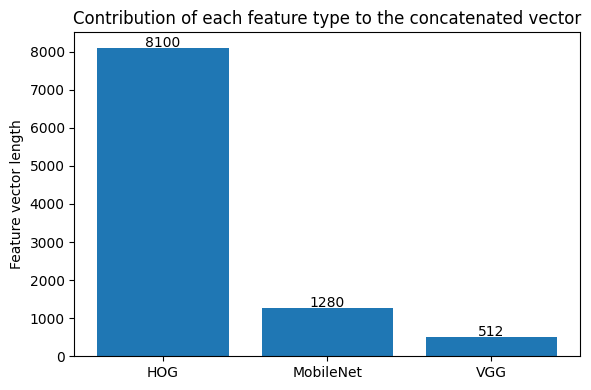

In [13]:
feature_dims = [rafdb_hog.shape[1], rafdb_mobilenet.shape[1], rafdb_vgg.shape[1]]
feature_names = ['HOG', 'MobileNet', 'VGG']

plt.figure(figsize=(6, 4))
bars = plt.bar(feature_names, feature_dims)
plt.ylabel("Feature vector length")
plt.title("Contribution of each feature type to the concatenated vector")
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
              str(bar.get_height()), ha='center')
plt.tight_layout()
plt.show()


## Step 6 — Train the SVM on RAF-DB

In [14]:
final_clf = SVC(kernel='linear', probability=True)
final_clf.fit(X_train_concat, y_train)

print(f"SVM trained on {len(y_train)} RAF-DB images.")


SVM trained on 1271 RAF-DB images.


## Step 7 — Load and Preprocess JAFFE (the Test Set)




In [15]:
jaffe_path = "/kaggle/input/datasets/navneet0094/jafee-dataset-la/jaffe"

jaffe_emotion_map = {
    'AN': 0, 'DI': 1, 'FE': 2,
    'HA': 3, 'SA': 4, 'SU': 5, 'NE': 6
}

jaffe_images, jaffe_labels = [], []

for img_name in sorted(os.listdir(jaffe_path)):
    try:
        img_path = os.path.join(jaffe_path, img_name)
        img = Image.open(img_path).convert('RGB')
        img = np.array(img)

        emotion_code = img_name.split('.')[1][:2]
        label = jaffe_emotion_map[emotion_code]

        jaffe_images.append(img)
        jaffe_labels.append(label)

    except Exception as e:
        print("Skipped:", img_name, "-", e)

jaffe_labels = np.array(jaffe_labels)
print("Total JAFFE images:", len(jaffe_images))
print("Label counts:", dict(zip(*np.unique(jaffe_labels, return_counts=True))))


Total JAFFE images: 213
Label counts: {np.int64(0): np.int64(30), np.int64(1): np.int64(29), np.int64(2): np.int64(32), np.int64(3): np.int64(31), np.int64(4): np.int64(31), np.int64(5): np.int64(30), np.int64(6): np.int64(30)}


In [16]:
jaffe_aligned, jaffe_labels_aligned = detect_align_batch(jaffe_images, jaffe_labels, dataset_name="JAFFE test")


  [JAFFE test] landmark detection: 200/213 processed
[JAFFE test] Landmarks detected + aligned for 213/213 images


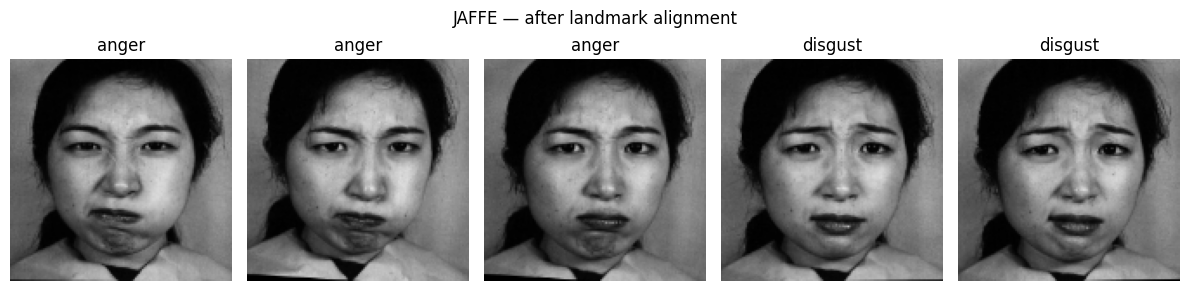

In [17]:
plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(jaffe_aligned[i])
    plt.title(emotion_names[jaffe_labels_aligned[i]])
    plt.axis('off')
plt.suptitle("JAFFE — after landmark alignment")
plt.tight_layout()
plt.show()


In [18]:
jaffe_hog = extract_hog_features(jaffe_aligned)
jaffe_mobilenet = extract_cnn_features(jaffe_aligned, mobilenet, mnet_preprocess)
jaffe_vgg = extract_cnn_features(jaffe_aligned, vgg, vgg_preprocess)

# transform using the scalers fitted on RAF-DB — do NOT re-fit here
jaffe_hog_scaled = hog_scaler.transform(jaffe_hog)
jaffe_mnet_scaled = mnet_scaler.transform(jaffe_mobilenet)
jaffe_vgg_scaled = vgg_scaler.transform(jaffe_vgg)

X_test_concat = np.concatenate([jaffe_hog_scaled, jaffe_mnet_scaled, jaffe_vgg_scaled], axis=1)
y_test = jaffe_labels_aligned

print("JAFFE concatenated feature shape:", X_test_concat.shape)


JAFFE concatenated feature shape: (213, 9892)


## Step 8 — Cross-Dataset Results: RAF-DB-Trained Model on JAFFE

In [19]:
probs = final_clf.predict_proba(X_test_concat)
y_pred = np.argmax(probs, axis=1)
y_conf = np.max(probs, axis=1)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print(f"RAF-DB-trained model evaluated on {len(y_test)} JAFFE images")
print(f"Cross-Dataset Accuracy: {acc:.4f}")
print(f"Cross-Dataset Macro F1: {f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=emotion_names, zero_division=0))


RAF-DB-trained model evaluated on 213 JAFFE images
Cross-Dataset Accuracy: 0.2347
Cross-Dataset Macro F1: 0.1979

              precision    recall  f1-score   support

       anger       0.27      0.10      0.15        30
     disgust       0.83      0.17      0.29        29
        fear       0.16      0.22      0.18        32
       happy       0.00      0.00      0.00        31
     sadness       0.22      0.35      0.27        31
    surprise       0.26      0.70      0.38        30
     neutral       0.14      0.10      0.12        30

    accuracy                           0.23       213
   macro avg       0.27      0.24      0.20       213
weighted avg       0.26      0.23      0.20       213



In [20]:
# cm = confusion_matrix(y_test, y_pred)

# plt.figure(figsize=(7, 6))
# plt.imshow(cm, cmap='Blues')
# plt.colorbar()
# plt.xticks(range(len(emotion_names)), emotion_names, rotation=45)
# plt.yticks(range(len(emotion_names)), emotion_names)
# plt.xlabel("Predicted")
# plt.ylabel("True")
# plt.title("Confusion Matrix — RAF-DB-trained model on JAFFE")

# for i in range(cm.shape[0]):
#     for j in range(cm.shape[1]):
#         plt.text(j, i, cm[i, j], ha='center', va='center',
#                   color='white' if cm[i, j] > cm.max() / 2 else 'black')

# plt.tight_layout()
# plt.show()


In [21]:
# f1_per_class = f1_score(y_test, y_pred, average=None, labels=range(7))

# plt.figure(figsize=(8, 4))
# bars = plt.bar(emotion_names, f1_per_class, color='darkorange')
# plt.ylabel("F1 score")
# plt.title("Per-Class F1 — RAF-DB-trained model on JAFFE")
# plt.xticks(rotation=30)
# for bar in bars:
#     plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
#               f"{bar.get_height():.2f}", ha='center')
# plt.tight_layout()
# plt.show()


In [22]:
# # a mix of correct and incorrect predictions
# correct_idx = np.where(y_pred == y_test)[0]
# wrong_idx = np.where(y_pred != y_test)[0]

# show_correct = np.random.choice(correct_idx, min(5, len(correct_idx)), replace=False)
# show_wrong = np.random.choice(wrong_idx, min(5, len(wrong_idx)), replace=False) if len(wrong_idx) > 0 else []

# plt.figure(figsize=(15, 6))
# for row, idx_list, row_title in [(0, show_correct, "Correct"), (1, show_wrong, "Incorrect")]:
#     for col, idx in enumerate(idx_list):
#         plt.subplot(2, 5, row * 5 + col + 1)
#         plt.imshow(jaffe_aligned[idx])
#         color = 'green' if row == 0 else 'red'
#         plt.title(f"True: {emotion_names[y_test[idx]]}\n"
#                   f"Pred: {emotion_names[y_pred[idx]]} ({y_conf[idx]*100:.0f}%)",
#                   color=color, fontsize=9)
#         plt.axis('off')
# plt.suptitle("JAFFE Cross-Dataset Predictions — Correct (top) vs. Incorrect (bottom)")
# plt.tight_layout()
# plt.show()
